# ML Modeling: Linear Regression Analysis for GDM Association

## Overview
This notebook performs linear regression analysis to determine if there is a significant difference in metabolite levels between GDM positive and non-GDM women, while accounting for covariates. We will analyze cord blood metabolites and calculate effect sizes and adjusted p-values.

## Step 1-2: Set Up Big Loop for Each Metabolite (Cord Data)

We will create a loop that iterates over each metabolite. For cord data:
- Rows = samples  
- Columns = metabolites  
- For each metabolite i: extract metabolite[i] (all rows, ith column)
- Fit model: `lm(metabolite[i] ~ covariates)`

## Setup: Load Core Inputs (Self-Contained)

Loading:
- `cord_matrix` from `CORD_DATA_T`
- covariates and supplements from `src/raw/mata2022_caco_mar242022.xlsx`
- `Sample` IDs from the cord mapping file (for row alignment only)
- `covariate_matrix_num` (aligned to cord sample order)
- `ml_csv_dir` for outputs

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd

import statsmodels.formula.api as smf
import statsmodels.api as sm

In [2]:
# Self-contained setup: load metabolite matrix and build aligned covariate matrix

# Keep imports robust for notebook cwd differences
sys.path.insert(0, str(Path(os.getcwd()).parent.parent))
from src.utils.config import CORD_DATA_T, CORD_ANNO, OUTPUTS_DIR

# 1) Load cord metabolite matrix (rows=samples, columns=metabolites)
cord_matrix = pd.read_csv(CORD_DATA_T, index_col="Sample").astype(float)
cord_matrix.index = cord_matrix.index.astype(str)

# 2) Load raw maternal covariate file (source of supplements + lifestyle covariates)
src_dir = Path(CORD_DATA_T).resolve().parents[2]
mata_path = src_dir / "raw" / "mata2022_caco_mar242022.xlsx"
if not mata_path.exists():
    raise FileNotFoundError(f"Required maternal covariate file not found: {mata_path}")

mata_df = pd.read_excel(mata_path)

# 3) Load Sample ID bridge from cord mapping output (used only for sample alignment)
gdm_map_path = os.path.join(OUTPUTS_DIR, "pca", "output_csv", "06_pc_scores", "cord_mapped_with_pc1_pc2.csv")
if not os.path.exists(gdm_map_path):
    raise FileNotFoundError(f"Required mapping file not found: {gdm_map_path}")

sample_bridge = pd.read_csv(gdm_map_path)
required_bridge_cols = ["Sample", "IDCode"]
missing_bridge = [c for c in required_bridge_cols if c not in sample_bridge.columns]
if missing_bridge:
    raise ValueError(f"Mapping file missing required columns: {missing_bridge}")

sample_bridge = sample_bridge[required_bridge_cols].copy()
sample_bridge["Sample"] = sample_bridge["Sample"].astype(str).str.strip()
sample_bridge = sample_bridge[sample_bridge["Sample"].str.len() > 0]
sample_bridge["IDCode"] = pd.to_numeric(sample_bridge["IDCode"], errors="coerce")
sample_bridge = sample_bridge.dropna(subset=["IDCode"]).drop_duplicates(subset=["Sample"], keep="first")

# 4) Merge raw maternal covariates to Sample IDs via IDCode
map_df = sample_bridge.merge(mata_df, on="IDCode", how="left")
map_df = map_df.drop_duplicates(subset=["Sample"], keep="first").set_index("Sample")

# 5) Resolve required covariates by aliases (physical_activity is fixed to O2_PHYSACTIV)
covariate_aliases = {
    "maternal_age": ["Ma_age", "maternal_age"],
    "bmi": ["pre_BMI_new", "BMI", "Ma_BMI"],
    "diet_protein": ["diet_protein", "protein", "protein_intake"],
    "diet_fruit_vegetables": ["diet_vegfruit", "fruit_vegetable", "fruit_veg"],
}
required_physical_activity_col = "O2_PHYSACTIV"

# supplement_aliases = {
#     "supp_multivitamin": ["p4_MULTIVITAMIN", "multivitamin"],
#     "supp_calcium": ["p4_CALCIUM", "calcium"],
#     "supp_folate": ["p4_FOLATE"],
#     "supp_fishoil": ["p4_FISHOIL", "fishoil", "fish_oil"],
#     "supp_zinc": ["p4_ZINC", "zinc"],
#     "supp_vitamin_e": ["p4_VITE", "vitamin_e", "vite"],
# }

selected_covariates = {}
for label, aliases in covariate_aliases.items():
    selected = next((col for col in aliases if col in map_df.columns), None)
    if selected is not None:
        selected_covariates[label] = selected

if required_physical_activity_col not in map_df.columns:
    phys_candidates = [
        c for c in map_df.columns
        if "phys" in str(c).lower() or "activ" in str(c).lower()
    ]
    raise ValueError(
        f"Required physical activity column '{required_physical_activity_col}' not found in maternal file. "
        f"O1_JOBACTIVITY is intentionally excluded. Candidate activity-like columns: {phys_candidates}"
    )
selected_covariates["physical_activity"] = required_physical_activity_col

# Supplement mapping intentionally disabled for this run.

# 6) Align covariate rows to cord matrix row order
sample_order = cord_matrix.index
ordered_source_cols = ["GDM"] + list(selected_covariates.values())
if "GDM" not in map_df.columns:
    raise ValueError("GDM column not found after merging maternal covariates.")

covariate_matrix_raw = map_df.reindex(sample_order)[ordered_source_cols].copy()
covariate_matrix_raw.index.name = "Sample"

rename_map = {"GDM": "GDM"}
rename_map.update({src: label for label, src in selected_covariates.items()})
covariate_matrix_raw = covariate_matrix_raw.rename(columns=rename_map)

# 7) Build supplement-derived variables
# Supplement-derived covariates are intentionally commented out for this run:
# supp_any_mvf_ca_fol
# supp_any_of_6

# 8) Type handling: GDM and physical_activity as categorical factors; others numeric
covariate_matrix_num = covariate_matrix_raw.copy()
gdm_numeric = pd.to_numeric(covariate_matrix_num["GDM"], errors="coerce")
covariate_matrix_num["GDM"] = pd.Categorical(gdm_numeric, categories=[0, 1])

# physical_activity source coding: 1=No, 2=Yes -> model coding: 0=No, 1=Yes
phys_numeric = pd.to_numeric(covariate_matrix_num["physical_activity"], errors="coerce")
phys_observed = set(phys_numeric.dropna().unique())
if phys_observed.issubset({1, 2}):
    phys_binary = phys_numeric.map({1: 0, 2: 1})
elif phys_observed.issubset({0, 1}):
    phys_binary = phys_numeric
else:
    phys_binary = pd.Series(
        np.where(phys_numeric.isna(), np.nan, (phys_numeric > 0).astype(int)),
        index=phys_numeric.index,
    )
phys_binary = pd.array(phys_binary, dtype="Int64")
covariate_matrix_num["physical_activity"] = pd.Categorical(phys_binary, categories=[0, 1])

numeric_covariates = [c for c in covariate_matrix_num.columns if c not in ["GDM", "physical_activity"]]
covariate_matrix_num[numeric_covariates] = covariate_matrix_num[numeric_covariates].apply(pd.to_numeric, errors="coerce")

# Store covariates in the requested variable name
cov_matrix = covariate_matrix_num.copy()

# 9) Output directory for this analysis
ml_csv_dir = os.path.join(OUTPUTS_DIR, "ml_modeling", "output_csv", "08_cord_gdm")
os.makedirs(ml_csv_dir, exist_ok=True)

print("Setup complete")
print("Cord matrix shape:", cord_matrix.shape)
print("Covariate matrix shape:", cov_matrix.shape)
print("GDM dtype:", cov_matrix["GDM"].dtype)
print("physical_activity dtype:", cov_matrix["physical_activity"].dtype)
print("physical_activity levels (0=No, 1=Yes):", cov_matrix["physical_activity"].cat.categories.tolist())
print("Resolved numeric covariates:", numeric_covariates)
print("Maternal source file:", mata_path)
print("Output dir:", ml_csv_dir)

Setup complete
Cord matrix shape: (38, 981)
Covariate matrix shape: (38, 6)
GDM dtype: category
physical_activity dtype: category
physical_activity levels (0=No, 1=Yes): [0, 1]
Resolved numeric covariates: ['maternal_age', 'bmi', 'diet_protein', 'diet_fruit_vegetables']
Maternal source file: /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/raw/mata2022_caco_mar242022.xlsx
Output dir: /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/../outputs/ml_modeling/output_csv/08_cord_gdm


In [3]:
cord_matrix.head()

,107004,108005,109011,1101001,1101006,1102005,1102011,1102012,1102017,1102018,...,675024,675025,675026,675027,675028,675029,676007,677004,677011,634009
Sample,,,,,,,,,,,,,,,,,,,,,
sample-1,0.982920,0.997001,1.001218,1.001201,1.040406,1.000000,0.979128,0.897300,1.049986,0.918842,...,0.998943,0.995692,0.993673,1.006100,0.989948,0.995593,0.990328,0.977754,0.985770,0.976144
sample-2,0.991572,1.024139,1.014588,1.019298,0.853199,0.881035,1.010385,0.931008,1.059620,0.908615,...,1.001057,0.996019,1.003748,0.992310,1.000658,0.994897,1.012718,1.005144,1.000231,1.017369
sample-3,0.962144,0.972625,0.999607,0.891771,0.953293,1.001158,0.869336,0.897300,0.834241,0.908615,...,0.988019,0.990972,0.980308,0.982788,0.994468,0.983981,1.004100,0.979684,0.980854,0.961003
sample-4,1.005908,1.015966,1.000671,0.891771,0.853199,1.022224,0.869336,0.897300,0.943810,0.908615,...,0.983763,0.985011,0.993704,0.997537,0.998984,0.989069,1.023485,0.991362,0.981521,0.983039
sample-5,0.888982,0.989501,0.995799,1.092085,0.925969,1.022152,0.869336,0.897300,0.915130,0.908615,...,1.013374,1.007367,0.996035,0.987062,0.997701,1.008544,0.935841,0.986891,0.995214,0.979196


## Step 4: Create Covariate Matrix

Create a matrix of covariates that associates with cord blood samples. The order must match the metabolite data.

**Covariates to include:**
- Maternal age
- BMI
- Diet (protein, fruit&vegetables)
- Physical activity
- Supplements (special handling):
  - **Variable 1:** Any of (Multivitamin, Calcium, Folate) = 1, else 0
  - **Variable 2:** Any of all 6 (Multivitamin, Calcium, Folate, Fishoil, Zinc, Vitamin E) = 1, else 0

**Factor handling in this step:**
- GDM as categorical factor (0/1)
- physical_activity as categorical factor

In [4]:
import re as _re
from pathlib import Path as _Path
_si = pd.read_excel(
    _Path(CORD_DATA_T).resolve().parents[2] / "raw" / "MetaPro_cord_blood_Jan2022.xlsx",
    sheet_name="Sample Info", header=0)
_label_map = dict(zip(_si["SAMPLE ID"].astype(str), _si["Tube Label"].astype(str)))
_tube = [_re.sub(r"[A-Za-z].*", "", _label_map.get(s, "")) for s in cov_matrix.index]
_disp = cov_matrix.copy()
_disp.insert(0, "Tube_Label", _tube)
_disp.head(38)

,Tube_Label,GDM,maternal_age,bmi,diet_protein,diet_fruit_vegetables,physical_activity
Sample,,,,,,,
sample-1,20284,0,34,28.040378,4.50,4.50,1
sample-2,20159,1,28,25.217359,3.25,4.50,1
sample-3,20256,0,28,24.242424,12.50,12.50,1
sample-4,20187,1,37,22.375680,8.50,24.00,0
sample-5,20219,0,32,20.195578,30.00,30.00,1
sample-6,20190,1,33,21.875000,14.65,21.00,0
sample-7,20225,0,32,21.303949,14.65,21.00,0
sample-8,20199,0,32,24.034610,20.25,30.00,0
sample-9,20208,1,37,22.206331,15.00,27.00,0


## Step 5: Check for Missing Covariates and Data Cleaning

- Check rows/samples with missing covariates
- Ensure all numeric covariates are properly typed
- Document any data quality issues before modeling

In [5]:
# Add Glucose column to cov_matrix = mean(GLU0h, GLU1h, GLU2h)
import re as _re2
from pathlib import Path as _Path2

# Add Tube_Label as first column (reuse _tube from cell 7)
if "Tube_Label" not in cov_matrix.columns:
    cov_matrix.insert(0, "Tube_Label", _tube)

# Load clinical file
_clin = pd.read_excel(
    _Path2(CORD_DATA_T).resolve().parents[2] / "raw" / "mata2022_caco_mar242022.xlsx"
)

# Map sample IDs to stripped numeric tube labels (matches IDCode in clinical file)
_si2 = pd.read_excel(
    _Path2(CORD_DATA_T).resolve().parents[2] / "raw" / "MetaPro_cord_blood_Jan2022.xlsx",
    sheet_name="Sample Info", header=0
)
_label_map2 = dict(zip(_si2["SAMPLE ID"].astype(str), _si2["Tube Label"].astype(str)))
_tube_ids = [
    int(_re2.sub(r"[A-Za-z].*", "", _label_map2.get(s, "0")))
    for s in cov_matrix.index
]

# Replace -999 sentinel with NaN, then index by IDCode
_glu = _clin[["IDCode", "GLU0h", "GLU1h", "GLU2h"]].copy()
_glu[["GLU0h", "GLU1h", "GLU2h"]] = _glu[["GLU0h", "GLU1h", "GLU2h"]].replace(-999, np.nan)
_glu = _glu.set_index("IDCode")

# Compute mean of GLU0h, GLU1h, GLU2h for each sample (NaN-safe)
cov_matrix["Glucose"] = [
    _glu.loc[tid, ["GLU0h", "GLU1h", "GLU2h"]].mean()
    if tid in _glu.index else np.nan
    for tid in _tube_ids
]

cov_matrix.head(38)

,Tube_Label,GDM,maternal_age,bmi,diet_protein,diet_fruit_vegetables,physical_activity,Glucose
Sample,,,,,,,,
sample-1,20284,0,34,28.040378,4.50,4.50,1,6.340000
sample-2,20159,1,28,25.217359,3.25,4.50,1,7.420000
sample-3,20256,0,28,24.242424,12.50,12.50,1,5.190000
sample-4,20187,1,37,22.375680,8.50,24.00,0,NaN
sample-5,20219,0,32,20.195578,30.00,30.00,1,6.610000
sample-6,20190,1,33,21.875000,14.65,21.00,0,8.356667
sample-7,20225,0,32,21.303949,14.65,21.00,0,5.593333
sample-8,20199,0,32,24.034610,20.25,30.00,0,7.220000
sample-9,20208,1,37,22.206331,15.00,27.00,0,7.716667


In [6]:
# Mean-impute diet_fruit_vegetables column
impute_col = "diet_fruit_vegetables"

before_missing = cov_matrix[impute_col].isna().sum()
mean_val = cov_matrix[impute_col].mean(skipna=True)
cov_matrix[impute_col] = cov_matrix[impute_col].fillna(mean_val)
after_missing = cov_matrix[impute_col].isna().sum()

print(f"Mean value used for imputation: {mean_val}")
print(f"Missing before: {before_missing}")
print(f"Missing after:  {after_missing}")

Mean value used for imputation: 19.595945945945946
Missing before: 1
Missing after:  0


In [7]:
# KNN imputation for missing physical_activity values
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from IPython.display import display

target_col = "physical_activity"
knn_impute_df = cov_matrix.copy()

target_numeric = pd.to_numeric(knn_impute_df[target_col], errors="coerce")

# Exclude non-numeric identifier columns from features
feature_cols = [col for col in knn_impute_df.columns if col not in [target_col, "Tube_Label"]]
feature_matrix = knn_impute_df[feature_cols].apply(pd.to_numeric, errors="coerce")
feature_matrix = feature_matrix.fillna(feature_matrix.median(numeric_only=True)).fillna(0)

observed_mask = target_numeric.notna()
missing_mask = target_numeric.isna()

print(f"Missing physical_activity values: {int(missing_mask.sum())}")

missing_mask_array = np.asarray(missing_mask)
observed_mask_array = np.asarray(observed_mask)
missing_index = knn_impute_df.index[missing_mask_array]
observed_index = knn_impute_df.index[observed_mask_array]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(feature_matrix)

n_neighbors = min(5, int(observed_mask_array.sum()))
nn = NearestNeighbors(n_neighbors=n_neighbors, metric="euclidean")
nn.fit(scaled_features[observed_mask_array])
distances, neighbor_positions = nn.kneighbors(scaled_features[missing_mask_array])

imputation_rows = []
for sample_id, neighbor_pos, dist in zip(missing_index, neighbor_positions, distances):
    neighbor_samples = observed_index.to_numpy()[neighbor_pos]
    neighbor_labels = target_numeric.loc[neighbor_samples].astype(int).to_numpy()
    weights = 1 / (dist + 1e-8)
    weighted_vote = float(np.average(neighbor_labels, weights=weights))
    imputed_value = int(weighted_vote >= 0.5)
    knn_impute_df.loc[sample_id, target_col] = imputed_value
    imputation_rows.append({
        "sample_id": sample_id,
        "nearest_neighbors": ", ".join(neighbor_samples.tolist()),
        "neighbor_distances": [round(x, 4) for x in dist.tolist()],
        "neighbor_values": neighbor_labels.tolist(),
        "weighted_avg": round(weighted_vote, 4),
        "filled_value": imputed_value,
    })

cov_matrix[target_col] = pd.Categorical(
    pd.to_numeric(knn_impute_df[target_col], errors="coerce").astype("Int64"),
    categories=[0, 1],
)

imputation_table = pd.DataFrame(imputation_rows)
print("KNN imputation summary:")
display(imputation_table)

print("\nMissing values after KNN imputation:")
display(cov_matrix[[target_col]].isna().sum().to_frame(name="missing_count"))

cov_clean = cov_matrix.copy()
print("\nCreated cleaned covariate matrix: cov_clean")

Missing physical_activity values: 3
KNN imputation summary:


,sample_id,nearest_neighbors,neighbor_distances,neighbor_values,weighted_avg,filled_value
0,sample-11,"sample-31, sample-21, sample-35, sample-6, sam...","[1.1754, 1.8191, 1.978, 2.0702, 2.1101]","[0, 1, 0, 0, 1]",0.3575,0
1,sample-27,"sample-19, sample-6, sample-25, sample-15, sam...","[1.143, 1.4324, 1.6772, 1.6841, 2.0603]","[1, 0, 1, 0, 1]",0.6023,1
2,sample-38,"sample-12, sample-1, sample-3, sample-22, samp...","[1.5911, 1.6784, 1.8791, 1.9309, 2.0905]","[1, 1, 1, 1, 0]",0.8262,1



Missing values after KNN imputation:


,missing_count
physical_activity,0



Created cleaned covariate matrix: cov_clean


In [8]:
# Display full cleaned covariate matrix
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
display(cov_clean)
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

,Tube_Label,GDM,maternal_age,bmi,diet_protein,diet_fruit_vegetables,physical_activity,Glucose
Sample,,,,,,,,
sample-1,20284,0,34,28.040378,4.50,4.500000,1,6.340000
sample-2,20159,1,28,25.217359,3.25,4.500000,1,7.420000
sample-3,20256,0,28,24.242424,12.50,12.500000,1,5.190000
sample-4,20187,1,37,22.375680,8.50,24.000000,0,NaN
sample-5,20219,0,32,20.195578,30.00,30.000000,1,6.610000
sample-6,20190,1,33,21.875000,14.65,21.000000,0,8.356667
sample-7,20225,0,32,21.303949,14.65,21.000000,0,5.593333
sample-8,20199,0,32,24.034610,20.25,30.000000,0,7.220000
sample-9,20208,1,37,22.206331,15.00,27.000000,0,7.716667


In [9]:
# Mean-impute missing Glucose values
before_missing = cov_clean['Glucose'].isna().sum()
glucose_mean = cov_clean['Glucose'].mean(skipna=True)
cov_clean['Glucose'] = cov_clean['Glucose'].fillna(glucose_mean)
after_missing = cov_clean['Glucose'].isna().sum()

print(f'Mean value used: {glucose_mean:.4f}')
print(f'Missing before:  {before_missing}')
print(f'Missing after:   {after_missing}')
print()

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
display(cov_clean)
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

Mean value used: 6.8844
Missing before:  2
Missing after:   0



,Tube_Label,GDM,maternal_age,bmi,diet_protein,diet_fruit_vegetables,physical_activity,Glucose
Sample,,,,,,,,
sample-1,20284,0,34,28.040378,4.50,4.500000,1,6.340000
sample-2,20159,1,28,25.217359,3.25,4.500000,1,7.420000
sample-3,20256,0,28,24.242424,12.50,12.500000,1,5.190000
sample-4,20187,1,37,22.375680,8.50,24.000000,0,6.884444
sample-5,20219,0,32,20.195578,30.00,30.000000,1,6.610000
sample-6,20190,1,33,21.875000,14.65,21.000000,0,8.356667
sample-7,20225,0,32,21.303949,14.65,21.000000,0,5.593333
sample-8,20199,0,32,24.034610,20.25,30.000000,0,7.220000
sample-9,20208,1,37,22.206331,15.00,27.000000,0,7.716667


In [10]:
# Export cov_clean with Glucose for R
_export_dir = os.path.join(OUTPUTS_DIR, 'ml_modeling', 'Python_outputs', 'CSV_files')
os.makedirs(_export_dir, exist_ok=True)

_cov_export = cov_clean.drop(columns=['Tube_Label'], errors='ignore')
_cov_export.to_csv(os.path.join(_export_dir, 'cov_clean_glucose_from_python.csv'))
print(f'Exported cov_clean with Glucose: {_cov_export.shape}')
print(f'Columns: {list(_cov_export.columns)}')

Exported cov_clean with Glucose: (38, 7)
Columns: ['GDM', 'maternal_age', 'bmi', 'diet_protein', 'diet_fruit_vegetables', 'physical_activity', 'Glucose']


In [11]:
# Filter cord data to match available covariate samples
cord_clean = cord_matrix.loc[cov_clean.index]
print(f'Cord data shape after matching: {cord_clean.shape}')
cord_clean.head(38)

Cord data shape after matching: (38, 981)


,107004,108005,109011,1101001,1101006,1102005,1102011,1102012,1102017,1102018,...,675024,675025,675026,675027,675028,675029,676007,677004,677011,634009
Sample,,,,,,,,,,,,,,,,,,,,,
sample-1,0.982920,0.997001,1.001218,1.001201,1.040406,1.000000,0.979128,0.897300,1.049986,0.918842,...,0.998943,0.995692,0.993673,1.006100,0.989948,0.995593,0.990328,0.977754,0.985770,0.976144
sample-2,0.991572,1.024139,1.014588,1.019298,0.853199,0.881035,1.010385,0.931008,1.059620,0.908615,...,1.001057,0.996019,1.003748,0.992310,1.000658,0.994897,1.012718,1.005144,1.000231,1.017369
sample-3,0.962144,0.972625,0.999607,0.891771,0.953293,1.001158,0.869336,0.897300,0.834241,0.908615,...,0.988019,0.990972,0.980308,0.982788,0.994468,0.983981,1.004100,0.979684,0.980854,0.961003
sample-4,1.005908,1.015966,1.000671,0.891771,0.853199,1.022224,0.869336,0.897300,0.943810,0.908615,...,0.983763,0.985011,0.993704,0.997537,0.998984,0.989069,1.023485,0.991362,0.981521,0.983039
sample-5,0.888982,0.989501,0.995799,1.092085,0.925969,1.022152,0.869336,0.897300,0.915130,0.908615,...,1.013374,1.007367,0.996035,0.987062,0.997701,1.008544,0.935841,0.986891,0.995214,0.979196
sample-6,0.936415,0.966933,1.001511,1.085668,0.927951,0.932325,0.869336,0.897300,0.908219,0.908615,...,0.997477,0.999022,0.995918,1.002968,1.000558,1.007961,0.952366,0.994578,0.996525,1.022623
sample-7,0.926607,1.009271,1.002519,0.891771,0.932275,1.016664,0.951294,0.897300,0.948767,0.908615,...,0.997615,1.007898,1.006565,1.008951,1.002414,1.011545,0.982356,1.021793,1.007157,1.003329
sample-8,1.009554,0.958469,0.993411,0.891771,0.862778,1.135285,0.869336,0.897300,0.900094,0.908615,...,0.981457,0.974797,0.973705,0.970117,0.987070,0.978230,0.941691,0.977910,0.972407,0.981213
sample-9,0.979675,0.952346,0.989498,0.891771,1.050900,1.161139,1.054652,1.000000,1.154361,1.148013,...,1.011428,1.010358,1.015158,1.008852,1.010948,1.019142,1.005846,1.012244,1.005407,0.997826


In [12]:
# Load significant metabolites from R output (raw p < 0.1 from GDM analysis)
_r_sig_path = os.path.join(
    OUTPUTS_DIR, 'ml_modeling', 'R_outputs', 'CSV_files', 'metabolites_raw_p_lt_0_1.csv'
)
_r_sig = pd.read_csv(_r_sig_path)
_r_sig_ids = _r_sig['Metabolite'].astype(str).tolist()

# Filter cord_clean to only those metabolites
_available = [m for m in _r_sig_ids if m in cord_clean.columns]
cord_clean_sig = cord_clean[_available]

print(f'Significant metabolites from R output (raw p < 0.1): {len(_r_sig_ids)}')
print(f'Found in cord_clean: {len(_available)}')
print(f'cord_clean_sig shape: {cord_clean_sig.shape}')

Significant metabolites from R output (raw p < 0.1): 89
Found in cord_clean: 89
cord_clean_sig shape: (38, 89)


In [13]:
# Steps: Main loop over significant metabolites (R output raw p < 0.1)
# Model: lm(Glucose ~ metabolite[i] + covariates)

metabolite_annotations = list(cord_clean_sig.columns)
covariate_cols = [col for col in cov_clean.columns if col not in ['Glucose', 'Tube_Label']]

p_store    = []
beta_store = []

print(f'Starting loop over {len(metabolite_annotations)} metabolites...')

for i, metabolite_name in enumerate(metabolite_annotations, start=1):

    # 1) Extract metabolite i and combine with cov_clean
    model_data = pd.concat(
        [cord_clean_sig[metabolite_name].rename('metabolite'), cov_clean],
        axis=1
    ).dropna()

    if model_data.empty or model_data['metabolite'].std() == 0:
        p_store.append(np.nan)
        beta_store.append(np.nan)
        continue

    # 2) Fit lm(Glucose ~ metabolite + covariates)
    formula = 'Glucose ~ metabolite + ' + ' + '.join(covariate_cols)
    fit = sm.formula.ols(formula, data=model_data).fit()

    # 3) Extract p-value and beta for metabolite coefficient
    p_store.append(fit.pvalues.get('metabolite', np.nan))
    beta_store.append(fit.params.get('metabolite', np.nan))

print(f'\nLoop complete. Metabolites tested: {len(p_store)}')
print(f'  p-values stored: {len(p_store)}')
print(f'  betas stored:    {len(beta_store)}')

Starting loop over 89 metabolites...



Loop complete. Metabolites tested: 89
  p-values stored: 89
  betas stored:    89


# beta_store 
beta_store is the list of regression coefficients (β) for each metabolite from the linear model Glucose ~ metabolite[i] + covariates.

For each metabolite, β tells you:

1. How much Glucose changes for every 1-unit increase in that metabolite, after holding all other covariates constant
2. Direction: β > 0 → metabolite is positively associated with Glucose; β < 0 → negatively associated
3. Magnitude: larger |β| = stronger association
4. Example: if β = 0.42 for metabolite X, it means for every 1-unit increase in metabolite X, Glucose goes up by 0.42 mmol/L on average (controlling for GDM, BMI, age, etc.)

5. It's the effect size — the p-value tells you whether the association is significant, and β tells you how strong and in which direction it is.

In [14]:
# Step 14: Convert to arrays
p_array    = np.array(p_store)
beta_array = np.array(beta_store)

print('Results vectors prepared:')
print(f'  p-values : {len(p_array)}')
print(f'  betas    : {len(beta_array)}')

print(f'\nP-value summary (89 metabolites, R output raw p < 0.1):')
print(f'  Min    : {np.nanmin(p_array):.4e}')
print(f'  Max    : {np.nanmax(p_array):.4f}')
print(f'  Median : {np.nanmedian(p_array):.4f}')
print(f'  NaNs   : {np.isnan(p_array).sum()}')
print(f'\n  Raw p < 0.05 : {(p_array < 0.05).sum()}')
print(f'  Raw p < 0.1  : {(p_array < 0.1).sum()}')

Results vectors prepared:
  p-values : 89
  betas    : 89

P-value summary (89 metabolites, R output raw p < 0.1):
  Min    : 2.9617e-02
  Max    : 0.9835
  Median : 0.5431
  NaNs   : 0

  Raw p < 0.05 : 2
  Raw p < 0.1  : 3


In [15]:
# Step 15: Benjamini-Hochberg FDR correction
from statsmodels.stats.multitest import multipletests

valid_mask = ~np.isnan(p_array)
pvals_adj_bh = np.full(len(p_array), np.nan)
reject_bh    = np.zeros(len(p_array), dtype=bool)

reject_valid, pvals_valid, _, _ = multipletests(p_array[valid_mask], method='fdr_bh')
pvals_adj_bh[valid_mask] = pvals_valid
reject_bh[valid_mask]    = reject_valid

print('Benjamini-Hochberg Correction Results:')
print(f'  Significant metabolites (FDR < 0.1): {reject_bh.sum()}')
print(f'  Min adjusted p-value:                  {np.nanmin(pvals_adj_bh):.4e}')
print(f'  Median adjusted p-value:               {np.nanmedian(pvals_adj_bh):.4f}')

Benjamini-Hochberg Correction Results:
  Significant metabolites (FDR < 0.1): 0
  Min adjusted p-value:                  9.8354e-01
  Median adjusted p-value:               0.9835


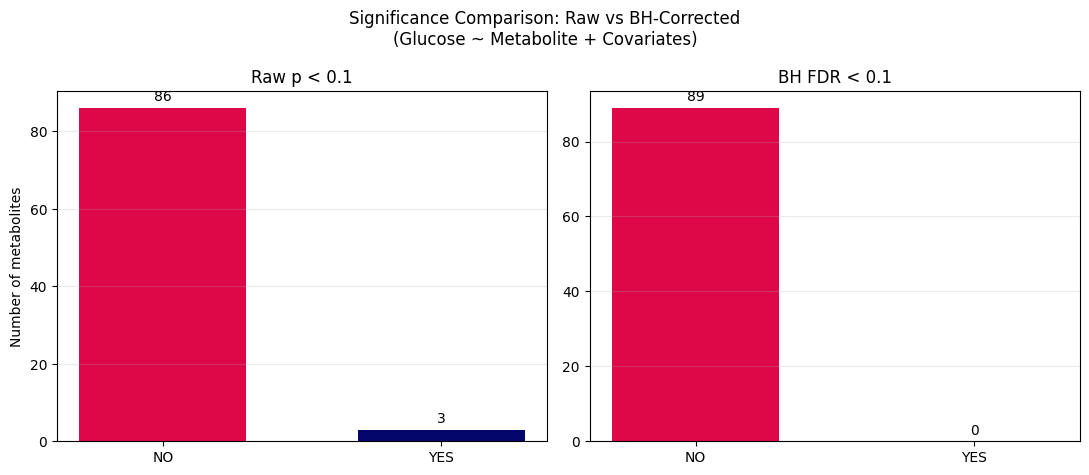

Raw p < 0.1 : 3/89
FDR < 0.1   : 0/89


In [16]:
# Before vs After Correction: Raw p<0.1 vs BH FDR<0.1
import matplotlib.pyplot as plt

alpha = 0.1
valid = ~np.isnan(p_array)
n_total = valid.sum()

raw_yes = int((p_array[valid] < alpha).sum())
raw_no  = n_total - raw_yes
fdr_yes = int((pvals_adj_bh[valid] < alpha).sum())
fdr_no  = n_total - fdr_yes

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

# Panel 1: Raw p < 0.05
bars1 = axes[0].bar(['NO', 'YES'], [raw_no, raw_yes], color=['#de0848', '#04066c'], width=0.6)
axes[0].set_title('Raw p < 0.1')
axes[0].set_ylabel('Number of metabolites')
axes[0].grid(axis='y', alpha=0.25)
for b in bars1:
    axes[0].text(
        b.get_x() + b.get_width() / 2,
        b.get_height() + max(1, n_total * 0.01),
        f'{int(b.get_height())}',
        ha='center', va='bottom', fontsize=10
    )

# Panel 2: FDR < 0.05
bars2 = axes[1].bar(['NO', 'YES'], [fdr_no, fdr_yes], color=['#de0848', '#a018d2'], width=0.6)
axes[1].set_title('BH FDR < 0.1')
axes[1].grid(axis='y', alpha=0.25)
for b in bars2:
    axes[1].text(
        b.get_x() + b.get_width() / 2,
        b.get_height() + max(1, n_total * 0.01),
        f'{int(b.get_height())}',
        ha='center', va='bottom', fontsize=10
    )

fig.suptitle('Significance Comparison: Raw vs BH-Corrected\n(Glucose ~ Metabolite + Covariates)', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Raw p < 0.1 : {raw_yes}/{n_total}')
print(f'FDR < 0.1   : {fdr_yes}/{n_total}')

In [17]:
# Step 16: Q-values (Storey's approach; fallback to BH if package unavailable)
try:
    from qvalue import qvalue
    q_vals = qvalue(p_array)['qvalues']
    print('Q-values calculated using qvalue package')
except ImportError:
    q_vals = pvals_adj_bh
    print('qvalue package not available — using BH adjusted p-values as q-values')

print(f'\nQ-value summary:')
print(f'  Min:    {np.nanmin(q_vals):.4e}')
print(f'  Median: {np.nanmedian(q_vals):.4f}')

qvalue package not available — using BH adjusted p-values as q-values

Q-value summary:
  Min:    9.8354e-01
  Median: 0.9835


In [18]:
# Step 17: Create results table and save
import os

# Load metabolite annotations
anno_df = pd.read_csv(CORD_ANNO, index_col=0) if CORD_ANNO else None

results_df = pd.DataFrame({
    'Metabolite':  metabolite_annotations,
    'Beta':        beta_array,
    'p_value_raw': p_array,
    'p_value_BH':  pvals_adj_bh,
    'q_value':     q_vals,
})

# Merge metabolite annotations
if anno_df is not None:
    results_df = results_df.merge(
        anno_df.reset_index(), left_on='Metabolite', right_on=anno_df.index.name, how='left'
    )

results_df = results_df.sort_values('p_value_raw').reset_index(drop=True)

# Save to outputs/10_Cord_Glucose_Analysis Outputs/Cord/Python_outputs
save_dir = os.path.join(OUTPUTS_DIR, '10_Cord_Glucose_Analysis Outputs', 'Cord', 'Python_outputs')
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, 'cord_glucose_ols_results.csv')
results_df.to_csv(save_path, index=False)

print(f'Results saved to: {save_path}')
print(f'Shape: {results_df.shape}')
print(f'\nTop 10 metabolites by p-value:')
results_df.head(10)

Results saved to: /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/../outputs/10_Cord_Glucose_Analysis Outputs/Cord/Python_outputs/cord_glucose_ols_results.csv
Shape: (89, 16)

Top 10 metabolites by p-value:


,Metabolite,Beta,p_value_raw,p_value_BH,q_value,COMP ID,COMPOUND Name,SUPER META PATHWAY,SUB META PATHWAY,ACQUISITION METHOD,HMDB ID,HMDB_annotation,PUBCHEM ID,CAS ID,KEGG ID,CHEMSPIDER ID
0,612027,-23.412929,0.029617,0.983535,0.983535,612027,palmitoyl ethanolamide,Lipid,Endocannabinoid,NEGa,HMDB0002100,NaN,4671.0,544-31-0,C16512,4509.0
1,644005,9.828576,0.048648,0.983535,0.983535,644005,caproate (6:0),Lipid,Medium Chain Fatty Acid,NEGa,HMDB0000535,NaN,8892.0,142-62-1,C01585,8552.0
2,313007,-4.711483,0.067344,0.983535,0.983535,313007,retinol (Vitamin A),Cofactors and Vitamins,Vitamin A Metabolism,POSb,HMDB0000305,NaN,445354.0,68-26-8,C17276,NaN
3,644006,6.956515,0.100291,0.983535,0.983535,644006,caprylate (8:0),Lipid,Medium Chain Fatty Acid,NEGa,HMDB0000482,NaN,379.0,124-07-2,C06423,370.0
4,112023,10.989186,0.117052,0.983535,0.983535,112023,beta-hydroxyisovalerate,Amino Acid,"Leucine, Isoleucine and Valine Metabolism",NEGa,HMDB0000754,NaN,69362.0,625-08-1,NaN,62571.0
5,1103008,-19.923593,0.133764,0.983535,0.983535,1103008,"2,4-di-tert-butylphenol",Xenobiotics,Chemical,NEGa,NaN,NaN,NaN,NaN,NaN,NaN
6,675012,-14.153919,0.138845,0.983535,0.983535,675012,"sphingomyelin (d18:1/20:0, d16:1/22:0)*",Lipid,Sphingomyelins,POSb,HMDB0012102,NaN,44260124.0,121999-68-6,C00550,23113477.0
7,624016,-11.382989,0.157296,0.983535,0.983535,624016,2-hydroxystearate,Lipid,"Fatty Acid, Monohydroxy",NEGa,HMDB0062549,NaN,439887.0,26531-80-6,C03045,NaN
8,114009,-3.845925,0.168010,0.983535,0.983535,114009,cysteine s-sulfate,Amino Acid,"Methionine, Cysteine, SAM and Taurine Metabolism",POSa,HMDB0000731,NaN,115015.0,1637-71-4,C05824,102939.0
9,616011,2.331376,0.174839,0.983535,0.983535,616011,4-methylnonanoylcarnitine,Lipid,"Fatty Acid Metabolism (Acyl Carnitine, Medium ...",POSb,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
export_dir = os.path.join(OUTPUTS_DIR, "Intermidiate_Datasets", "Cord")
os.makedirs(export_dir, exist_ok=True)

cov_matrix.to_csv(os.path.join(export_dir, "cov_matrix_glucose.csv"))
cov_clean.to_csv(os.path.join(export_dir, "cov_clean_glucose.csv"))

print(f"Exported to: {export_dir}")
print(f"  cov_matrix (with Glucose, before cleaning): {cov_matrix.shape}")
print(f"  cov_clean  (after cleaning):                {cov_clean.shape}")